### Installing necessary Libraries

In [1]:
!pip install -q ir_datasets python-terrier

### Import Neccessary Libraries

In [2]:
import pandas as pd
import numpy as np
import joblib
import warnings
import ir_datasets
import seaborn as sns
import ir_measures 
import pyterrier as pt
from ir_measures import nDCG
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import RidgeCV

import warnings
warnings.filterwarnings("ignore")

### Load Retrieval Scores and Trained SVM Model

In [3]:
dataset = ir_datasets.load('sara')

# Load the raw retrieval results
colbert_results = pd.read_csv("./retrieval_scores/colbert_scores.csv")
splade_results = pd.read_csv("./retrieval_scores/splade_scores.csv")
reranking_results = pd.read_csv("./retrieval_scores/colbert+splade_scores.csv")
svm_model_path = "./trained_classifier/sensitivity_classifier.pkl"

print(f"{len(colbert_results)} ColBERT Results loaded ")
print(f"{len(splade_results)} SPLADE Results loaded ")
print(f"{len(reranking_results)} ColBERT+SPLADE re-ranking results loaded")

15000 ColBERT Results loaded 
15000 SPLADE Results loaded 
15000 ColBERT+SPLADE re-ranking results loaded


### Data Preparation and Document Sensitivity Prediction

In [4]:
# Merges SARA data onto a results DataFrame and applies a trained SVM to add sensitivity probability predictions.
def prepare_and_predict_sensitivity(results_df: pd.DataFrame, svm_path: str, sara_dataset) -> pd.DataFrame:
    
    # Load SARA documents and relevance judgments (qrels)
    docs_df = pd.DataFrame(sara_dataset.docs_iter()).rename(columns={'doc_id': 'docno'})
    qrels_df = pd.DataFrame(sara_dataset.qrels_iter()).rename(columns={'query_id': 'qid', 'doc_id': 'docno', 'relevance': 'label'})
    
    # Ensure consistent string types for merging keys
    for df in [results_df, docs_df, qrels_df]:
        for col in ['qid', 'docno']:
            if col in df.columns:
                df[col] = df[col].astype(str)

    # Merge text, true sensitivity, and relevance labels
    merged_df = results_df.merge(docs_df[['docno', 'text', 'sensitivity']], on='docno', how='left')
    merged_df = merged_df.merge(qrels_df[['qid', 'docno', 'label']], on=['qid', 'docno'], how='left')
    merged_df['label'] = merged_df['label'].fillna(0).astype(int)
    
    # Load the trained SVM classifier
    svm_classifier = joblib.load(svm_path)
    
    # Predict on unique documents to be efficient
    unique_docs_df = merged_df.drop_duplicates(subset=['docno'])
    unique_texts = unique_docs_df['text'].fillna('') # Handle potential missing text
    
    # We select [:, 1] for the probability of the "sensitive" class
    sensitivity_probs = svm_classifier.predict_proba(unique_texts)[:, 1]
    
    # Create a mapping from docno -> predicted_probability
    sensitivity_map = dict(zip(unique_docs_df['docno'], sensitivity_probs))
    
    # Add the predictions to the main DataFrame
    merged_df['sensitivity_probability'] = merged_df['docno'].map(sensitivity_map).fillna(0)
    
    return merged_df

In [5]:
# Load SARA dataset and extract components
dataset = ir_datasets.load("sara")
qrels = pd.DataFrame(dataset.qrels_iter())
topics = dataset.queries_iter()

# Complete dataset preparation
colbert_full = prepare_and_predict_sensitivity(colbert_results, svm_model_path, dataset)
splade_full = prepare_and_predict_sensitivity(splade_results, svm_model_path, dataset)
rerank_full = prepare_and_predict_sensitivity(reranking_results, svm_model_path, dataset)

In [6]:
print(colbert_full.shape)
colbert_full.head(2)

(15000, 8)


,qid,docno,score,rank,text,sensitivity,label,sensitivity_probability
0,1,174414,11.296875,0,Message-ID: <22235573.1075846177434.JavaMail.e...,0,0,0.000382
1,1,173952,11.101562,1,Message-ID: <25788753.1075846163828.JavaMail.e...,0,0,0.000917


In [7]:
print(splade_full.shape)
splade_full.head(2)

(15000, 9)


,Unnamed: 0,qid,docno,score,rank,text,sensitivity,label,sensitivity_probability
0,0,1,191480,6.876581,0,Message-ID: <19247154.1075854433719.JavaMail.e...,0,0,0.000881
1,1,1,135767,6.153024,1,Message-ID: <26181614.1075844207094.JavaMail.e...,0,0,0.000267


In [8]:
print(rerank_full.shape)
rerank_full.head(2)

(15000, 12)


,Unnamed: 0,qid,docno,score,colbert_score,splade_score,colbert_rank,rank,text,sensitivity,label,sensitivity_probability
0,0,1,120514,6.148226,10.804688,6.148226,3,0,Message-ID: <27496700.1075843385860.JavaMail.e...,0,0,0.000439
1,1,1,175162,6.029333,8.593750,6.029333,36,1,Message-ID: <31218520.1075847578460.JavaMail.e...,1,0,0.488716


### Sensitive Document Percentage in Top-k Results for Baseline Models

In [9]:
# Compute per-query percentage of sensitive docs in top-k, then average over queries.
def compute_sensitive_percentage(results, topk=10):

    summary_rows = []

    for model_name, df in results.items():
        df['qid'] = df['qid'].astype(str)  # ensure qid is string
        per_query_percent = []

        for qid, group in df.groupby('qid'):
            topk_docs = group.sort_values('score', ascending=False).head(topk)
            num_sensitive = (topk_docs['sensitivity'] == 1).sum()
            percent_sensitive = (num_sensitive / topk) * 100
            per_query_percent.append(percent_sensitive)

        # Macro-average over all queries
        macro_avg_percent = sum(per_query_percent) / len(per_query_percent) if per_query_percent else 0
        summary_rows.append({
            'Model': model_name,
            'Avg Sens Docs (%)': round(macro_avg_percent, 2)
        })

    return pd.DataFrame(summary_rows)

results = {
    "ColBERT": colbert_full,
    "SPLADE": splade_full,
    "ColBERT+SPLADE": rerank_full
}

summary_table = compute_sensitive_percentage(results, topk=10)
summary_table

,Model,Avg Sens Docs (%)
0,ColBERT,8.93
1,SPLADE,10.93
2,ColBERT+SPLADE,9.67


#### Defining variables and constants

In [10]:
# Dictionary mapping model names to their corresponding DataFrames
data_to_process = {
    "ColBERT": colbert_full,
    "SPLADE": splade_full,
    "ColBERT→SPLADE": rerank_full
}

# Number of top-ranked documents to consider (top-k cutoff)
K = 10  

# Threshold parameter (tau) is used as a decision boundary or filtering criterion
TAU = 0.5  

# This represents the cost penalty for exposing sensitive documents
CS_VALUE = 12.0  

# alpha is used as a parameter sweep
alphas = np.round(np.arange(0.1, 1.0, 0.1), 1)

### Cost-Sensitive Evaluation and Score Fusion Functions

In [11]:
def calculate_additive_cs_ndcg(query_group, k, tau, Cs):
    # Calculates the normalized, additive CS-DCG for a single query group
    ranked_docs = query_group.sort_values('score', ascending=False).head(k)
    cs_dcg = 0.0; best_cs_dcg = 0.0; worst_cs_dcg = 0.0
    
    # Calculate actual CS-DCG for the current ranking
    for i, (_, doc) in enumerate(ranked_docs.iterrows(), 1):
        gain = 2**doc['label'] - 1
        discount = np.log2(i + 1)
        cost = Cs if doc['sensitivity_probability'] >= tau else 0
        cs_dcg += (gain / discount) - cost
        
    # Calculate ideal CS-DCG
    ideal_group = query_group.copy()
    ideal_group['ideal_key'] = (2**ideal_group['label'] - 1) - (Cs * (ideal_group['sensitivity_probability'] >= tau))
    ideal_ranking = ideal_group.sort_values('ideal_key', ascending=False).head(k)
    
    for i, (_, doc) in enumerate(ideal_ranking.iterrows(), 1):
        gain = 2**doc['label'] - 1
        discount = np.log2(i + 1)
        cost = Cs if doc['sensitivity_probability'] >= tau else 0
        best_cs_dcg += (gain / discount) - cost
        
    # Calculate worst CS-DCG
    worst_group = query_group.copy()
    worst_group['worst_key'] = -(2**worst_group['label'] - 1) + (Cs * (worst_group['sensitivity_probability'] >= tau))
    worst_ranking = worst_group.sort_values('worst_key', ascending=False).head(k)
    
    for i, (_, doc) in enumerate(worst_ranking.iterrows(), 1):
        gain = 2**doc['label'] - 1
        discount = np.log2(i + 1)
        cost = Cs if doc['sensitivity_probability'] >= tau else 0
        worst_cs_dcg += (gain / discount) - cost
        
    # Normalize CS-DCG to [0,1] range
    return (cs_dcg - worst_cs_dcg) / (best_cs_dcg - worst_cs_dcg) if (best_cs_dcg - worst_cs_dcg) != 0 else 0.0

def calculate_actual_sensitive_percentage(query_group, topk):
    # Macro-average percentage of sensitive docs in top-k per query.
    query_group['qid'] = query_group['qid'].astype(str)
    per_query_percent = []
    for qid, group in query_group.groupby('qid'):
        topk_docs = group.sort_values('score', ascending=False).head(topk)
        sensitive_count = (topk_docs['sensitivity'] == 1).sum()
        percent_sensitive = (sensitive_count / topk) * 100
        per_query_percent.append(percent_sensitive)
    macro_avg_percent = sum(per_query_percent) / len(per_query_percent) if per_query_percent else 0
    return round(macro_avg_percent, 2)

def evaluate(df, k, tau, Cs, qrels_formatted):
    # Comprehensive evaluation combining cost-sensitive and traditional IR metrics
    cs_ndcg_scores = [calculate_additive_cs_ndcg(group, k, tau, Cs) for _, group in df.groupby('qid')]
    sens_perc_scores = [calculate_actual_sensitive_percentage(group, k) for _, group in df.groupby('qid')]
    run_df = df[['qid', 'docno', 'score']].rename(columns={'qid': 'query_id', 'docno': 'doc_id'})
    results = ir_measures.calc_aggregate([nDCG@k], qrels_formatted, run_df)
    return {
        f'nCS-DCG@{k}': np.mean(cs_ndcg_scores),
        f'nDCG@{k}': results.get(nDCG@k, 0.0),
        f'Sens Docs(%)': np.mean(sens_perc_scores)
    }

def fuse_linear_scores(df, alpha, normalize=False):
    # Applies linear fusion to a dataframe
    fused_df = df.copy()
    relevance_score = fused_df['score'].values.reshape(-1, 1)
    if normalize:
        relevance_score = MinMaxScaler().fit_transform(relevance_score)
    sensitivity_prob = fused_df['sensitivity_probability'].values.reshape(-1, 1)
    fused_df['score'] = alpha * relevance_score + (1 - alpha) * (1 - sensitivity_prob)
    return fused_df

def fuse_harmonic_scores(df, alpha, normalize=False):
    # Applies harmonic mean fusion to a dataframe.
    fused_df = df.copy()
    relevance_values = fused_df['score'].values
    if normalize:
        relevance_values = MinMaxScaler().fit_transform(relevance_values.reshape(-1, 1)).flatten()
    sensitivity_values = fused_df['sensitivity_probability'].values
    epsilon = 1e-9
    score_safe = np.maximum(relevance_values, epsilon)
    sens_safe = np.minimum(sensitivity_values, 1 - epsilon)
    fused_df['score'] = 1 / ((alpha / score_safe) + ((1 - alpha) / (1 - sens_safe)))
    return fused_df

### Linear Fusion Evaluation Pipeline

In [12]:
colbert_results, splade_results, reranking_results = {}, {}, {}

# Create DataFrames for Linear Fusion Results
colbert_linear_fusion_df = None
splade_linear_fusion_df = None  
reranking_linear_fusion_df = None

for name, base_df in data_to_process.items():
    if name == "ColBERT": results_dict = colbert_results
    elif name == "SPLADE": results_dict = splade_results
    else: results_dict = reranking_results

    # Evaluate Baseline
    results_dict['Baseline'] = [evaluate(base_df, k=K, tau=TAU, Cs=CS_VALUE, qrels_formatted=qrels)]

    # Evaluate Linear Fusion 
    for norm_type in ['Raw', 'Normalized']:
        key = f'Linear ({norm_type})'
        results_dict[key] = []
        normalize = (norm_type == 'Normalized')
        for alpha in alphas:
            fused_df = fuse_linear_scores(base_df, alpha, normalize=normalize)
            fusion_metrics = evaluate(fused_df, k=K, tau=TAU, Cs=CS_VALUE, qrels_formatted=qrels)
            result_row = {'Alpha': alpha, **fusion_metrics}
            results_dict[key].append(result_row)

for name in data_to_process.keys():
    # Get the appropriate results based on the name
    if name == 'ColBERT':
        df_raw = pd.DataFrame(colbert_results[f'Linear (Raw)'])
        df_norm = pd.DataFrame(colbert_results[f'Linear (Normalized)'])
        baseline_df = pd.DataFrame(colbert_results['Baseline'])
    elif name == 'SPLADE':
        df_raw = pd.DataFrame(splade_results[f'Linear (Raw)'])
        df_norm = pd.DataFrame(splade_results[f'Linear (Normalized)'])
        baseline_df = pd.DataFrame(splade_results['Baseline'])
    else:  
        df_raw = pd.DataFrame(reranking_results[f'Linear (Raw)'])
        df_norm = pd.DataFrame(reranking_results[f'Linear (Normalized)'])
        baseline_df = pd.DataFrame(reranking_results['Baseline'])
    
    # Add metadata columns
    baseline_df['Fusion Type'] = 'Baseline'
    baseline_df['Alpha'] = 1.0
    df_raw['Fusion Type'] = 'Linear (Raw)'
    df_norm['Fusion Type'] = 'Linear (Normalized)'
    
    # Combine all three types
    full_df = pd.concat([baseline_df, df_raw, df_norm]).reset_index(drop=True)
    
    # Assign to the appropriate variable
    if name == 'ColBERT':
        colbert_linear_fusion_df = full_df.copy()
    elif name == 'SPLADE':
        splade_linear_fusion_df = full_df.copy()
    else:  # Reranking
        reranking_linear_fusion_df = full_df.copy()

In [13]:
colbert_linear_fusion_df = colbert_linear_fusion_df[["Alpha","Fusion Type", "nDCG@10","nCS-DCG@10","Sens Docs(%)"]]
colbert_linear_fusion_df

,Alpha,Fusion Type,nDCG@10,nCS-DCG@10,Sens Docs(%)
0,1.0,Baseline,0.116395,0.849926,8.933333
1,0.1,Linear (Raw),0.098709,0.954681,1.200000
2,0.2,Linear (Raw),0.098861,0.954687,1.266667
3,0.3,Linear (Raw),0.102566,0.945840,2.000000
4,0.4,Linear (Raw),0.103949,0.936714,2.666667
5,0.5,Linear (Raw),0.105355,0.923029,3.666667
6,0.6,Linear (Raw),0.106234,0.904733,5.000000
7,0.7,Linear (Raw),0.106108,0.895907,5.666667
8,0.8,Linear (Raw),0.111438,0.880244,6.933333
9,0.9,Linear (Raw),0.114902,0.865360,7.866667


In [14]:
splade_linear_fusion_df = splade_linear_fusion_df[["Alpha","Fusion Type", "nDCG@10","nCS-DCG@10","Sens Docs(%)"]]
splade_linear_fusion_df

,Alpha,Fusion Type,nDCG@10,nCS-DCG@10,Sens Docs(%)
0,1.0,Baseline,0.172984,0.822870,10.933333
1,0.1,Linear (Raw),0.142053,0.952946,0.933333
2,0.2,Linear (Raw),0.151964,0.927017,2.733333
3,0.3,Linear (Raw),0.155945,0.912689,3.666667
4,0.4,Linear (Raw),0.157047,0.902880,4.733333
5,0.5,Linear (Raw),0.160518,0.884962,6.200000
6,0.6,Linear (Raw),0.165681,0.864824,7.866667
7,0.7,Linear (Raw),0.169206,0.855346,8.666667
8,0.8,Linear (Raw),0.170388,0.843036,9.533333
9,0.9,Linear (Raw),0.172014,0.829926,10.466667


In [15]:
reranking_linear_fusion_df = reranking_linear_fusion_df[["Alpha","Fusion Type", "nDCG@10","nCS-DCG@10","Sens Docs(%)"]]
reranking_linear_fusion_df

,Alpha,Fusion Type,nDCG@10,nCS-DCG@10,Sens Docs(%)
0,1.0,Baseline,0.151695,0.826471,9.666667
1,0.1,Linear (Raw),0.123521,0.957836,1.400000
2,0.2,Linear (Raw),0.137921,0.935473,3.066667
3,0.3,Linear (Raw),0.141408,0.924032,3.800000
4,0.4,Linear (Raw),0.144620,0.901234,4.933333
5,0.5,Linear (Raw),0.148282,0.877031,6.533333
6,0.6,Linear (Raw),0.148355,0.860563,7.800000
7,0.7,Linear (Raw),0.149656,0.847373,8.533333
8,0.8,Linear (Raw),0.150434,0.842398,8.800000
9,0.9,Linear (Raw),0.150407,0.836413,9.000000


### Linear Fusion Performance Visualization

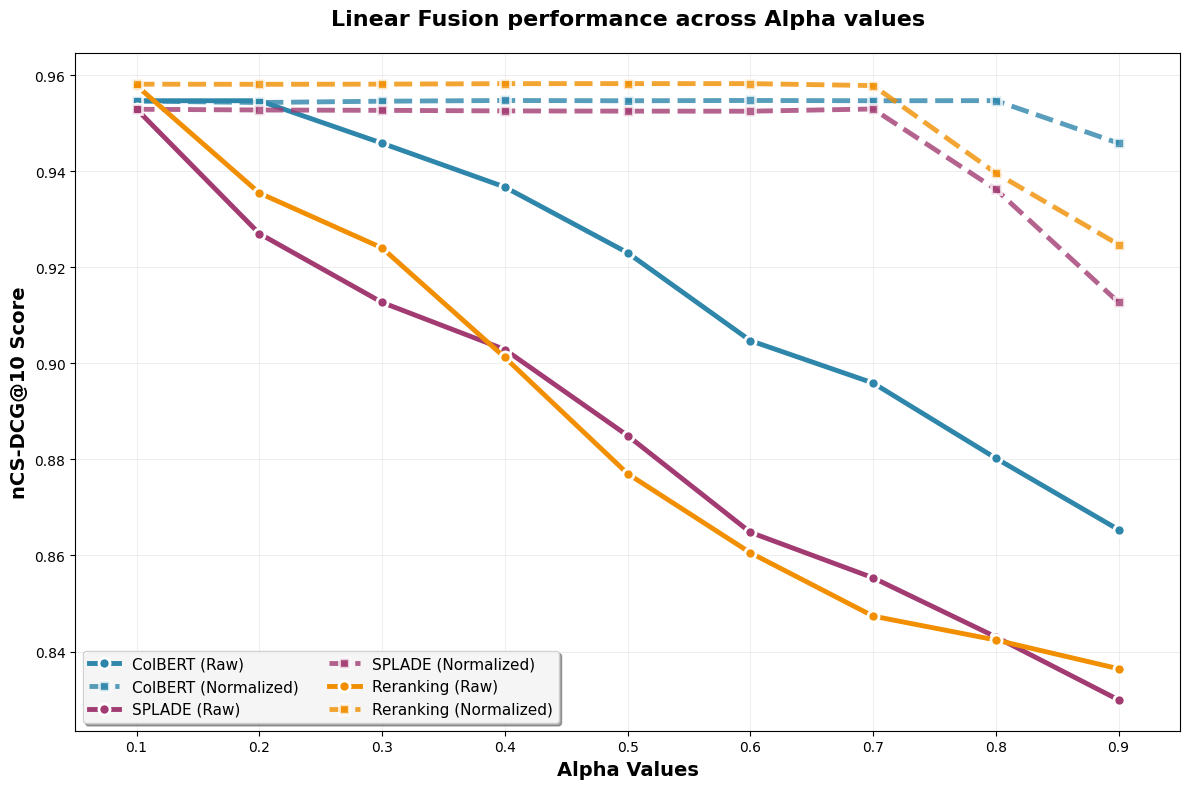

In [16]:
# Set up the plot 
plt.figure(figsize=(12, 8))
plt.style.use('default')

# Define colors for each dataset
colors = {
    'ColBERT': '#2E86AB',      # Blue
    'SPLADE': '#A23B72',       # Magenta  
    'Reranking': '#F18F01'     # Orange
}

# Dataset names and corresponding dataframes
datasets = {
    'ColBERT': colbert_linear_fusion_df,
    'SPLADE': splade_linear_fusion_df, 
    'Reranking': reranking_linear_fusion_df
}

# Plot each dataset
for dataset_name, df in datasets.items():
    color = colors[dataset_name]
    
    # Filter for Raw and Normalized data
    raw_data = df[df['Fusion Type'] == 'Linear (Raw)'].copy()
    norm_data = df[df['Fusion Type'] == 'Linear (Normalized)'].copy()
    
    # Sort by Alpha to ensure proper line connection
    raw_data = raw_data.sort_values('Alpha')
    norm_data = norm_data.sort_values('Alpha')
    
    # Plot Raw data with solid line
    # Plot Raw data with enhanced styling
    plt.plot(raw_data['Alpha'], raw_data['nCS-DCG@10'], 
             color=color, linewidth=3.5, linestyle='-', 
             marker='o', markersize=8, markerfacecolor=color,
             markeredgecolor='white', markeredgewidth=2,
             label=f'{dataset_name} (Raw)')
    
    # Plot Normalized data with enhanced styling
    plt.plot(norm_data['Alpha'], norm_data['nCS-DCG@10'], 
             color=color, linewidth=3.5, linestyle='--', 
             marker='s', markersize=7, markerfacecolor=color,
             markeredgecolor='white', markeredgewidth=2,
             label=f'{dataset_name} (Normalized)', alpha=0.8)
# Customize the plot
plt.xlabel('Alpha Values', fontsize=14, fontweight='bold')
plt.ylabel('nCS-DCG@10 Score', fontsize=14, fontweight='bold')
plt.title('Linear Fusion performance across Alpha values', 
          fontsize=16, fontweight='bold', pad=20)

# Set x-axis ticks
plt.xticks(np.arange(0.1, 1.0, 0.1))
plt.xlim(0.05, 0.95)

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Customize legend
plt.legend(loc='best', frameon=True, fancybox=True, shadow=True, 
           ncol=2, fontsize=11, framealpha=0.9)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()

### Harmonic Fusion Evaluation Pipeline

In [17]:
colbert_harmonic_results, splade_harmonic_results, reranking_harmonic_results = {}, {}, {}

# Create DataFrames for Harmonic Fusion Results
colbert_harmonic_fusion_df = None
splade_harmonic_fusion_df = None  
reranking_harmonic_fusion_df = None

for name, base_df in data_to_process.items():
    if name == "ColBERT": results_dict = colbert_harmonic_results
    elif name == "SPLADE": results_dict = splade_harmonic_results
    else: results_dict = reranking_harmonic_results

    # Evaluate Baseline
    results_dict['Baseline'] = [evaluate(base_df, k=K, tau=TAU, Cs=CS_VALUE, qrels_formatted=qrels)]

    # Evaluate Harmonic Fusion Only
    for norm_type in ['Raw', 'Normalized']:
        key = f'Harmonic ({norm_type})'
        results_dict[key] = []
        normalize = (norm_type == 'Normalized')
        for alpha in alphas:
            fused_df = fuse_harmonic_scores(base_df, alpha, normalize=normalize)
            fusion_metrics = evaluate(fused_df, k=K, tau=TAU, Cs=CS_VALUE, qrels_formatted=qrels)
            result_row = {'Alpha': alpha, **fusion_metrics}
            results_dict[key].append(result_row)

for name in data_to_process.keys():
    if name == 'ColBERT':
        df_raw = pd.DataFrame(colbert_harmonic_results[f'Harmonic (Raw)'])
        df_norm = pd.DataFrame(colbert_harmonic_results[f'Harmonic (Normalized)'])
        baseline_df = pd.DataFrame(colbert_harmonic_results['Baseline'])
    elif name == 'SPLADE':
        df_raw = pd.DataFrame(splade_harmonic_results[f'Harmonic (Raw)'])
        df_norm = pd.DataFrame(splade_harmonic_results[f'Harmonic (Normalized)'])
        baseline_df = pd.DataFrame(splade_harmonic_results['Baseline'])
    else:  # Reranking
        df_raw = pd.DataFrame(reranking_harmonic_results[f'Harmonic (Raw)'])
        df_norm = pd.DataFrame(reranking_harmonic_results[f'Harmonic (Normalized)'])
        baseline_df = pd.DataFrame(reranking_harmonic_results['Baseline'])
    
    baseline_df['Fusion Type'] = 'Baseline'
    baseline_df['Alpha'] = 1.0
    df_raw['Fusion Type'] = 'Harmonic (Raw)'
    df_norm['Fusion Type'] = 'Harmonic (Normalized)'
    
    full_df = pd.concat([baseline_df, df_raw, df_norm]).reset_index(drop=True)
    
    if name == 'ColBERT':
        colbert_harmonic_fusion_df = full_df.copy()
    elif name == 'SPLADE':
        splade_harmonic_fusion_df = full_df.copy()
    else:  # Reranking
        reranking_harmonic_fusion_df = full_df.copy()

In [18]:
colbert_harmonic_fusion_df = colbert_harmonic_fusion_df[["Alpha","Fusion Type", "nDCG@10","nCS-DCG@10","Sens Docs(%)"]]
colbert_harmonic_fusion_df

,Alpha,Fusion Type,nDCG@10,nCS-DCG@10,Sens Docs(%)
0,1.0,Baseline,0.116395,0.849926,8.933333
1,0.1,Harmonic (Raw),0.088006,0.953329,0.600000
2,0.2,Harmonic (Raw),0.093400,0.954221,0.533333
3,0.3,Harmonic (Raw),0.094772,0.954231,0.400000
4,0.4,Harmonic (Raw),0.095368,0.954357,0.600000
5,0.5,Harmonic (Raw),0.096230,0.954544,0.733333
6,0.6,Harmonic (Raw),0.096293,0.954505,0.733333
7,0.7,Harmonic (Raw),0.096692,0.954553,0.866667
8,0.8,Harmonic (Raw),0.095382,0.954384,1.000000
9,0.9,Harmonic (Raw),0.097127,0.954620,1.066667


In [19]:
splade_harmonic_fusion_df = splade_harmonic_fusion_df[["Alpha","Fusion Type", "nDCG@10","nCS-DCG@10","Sens Docs(%)"]]
splade_harmonic_fusion_df

,Alpha,Fusion Type,nDCG@10,nCS-DCG@10,Sens Docs(%)
0,1.0,Baseline,0.172984,0.822870,10.933333
1,0.1,Harmonic (Raw),0.135513,0.952238,0.466667
2,0.2,Harmonic (Raw),0.145146,0.953342,0.533333
3,0.3,Harmonic (Raw),0.145592,0.953247,0.466667
4,0.4,Harmonic (Raw),0.144487,0.953068,0.533333
5,0.5,Harmonic (Raw),0.142202,0.952770,0.600000
6,0.6,Harmonic (Raw),0.142264,0.952798,0.666667
7,0.7,Harmonic (Raw),0.141651,0.952679,0.733333
8,0.8,Harmonic (Raw),0.142484,0.952692,0.733333
9,0.9,Harmonic (Raw),0.141122,0.952523,0.800000


In [20]:
reranking_harmonic_fusion_df = reranking_harmonic_fusion_df[["Alpha","Fusion Type", "nDCG@10","nCS-DCG@10","Sens Docs(%)"]]
reranking_harmonic_fusion_df

,Alpha,Fusion Type,nDCG@10,nCS-DCG@10,Sens Docs(%)
0,1.0,Baseline,0.151695,0.826471,9.666667
1,0.1,Harmonic (Raw),0.119868,0.958417,0.666667
2,0.2,Harmonic (Raw),0.122018,0.958564,0.733333
3,0.3,Harmonic (Raw),0.123709,0.958756,0.733333
4,0.4,Harmonic (Raw),0.120884,0.958180,0.800000
5,0.5,Harmonic (Raw),0.119844,0.958004,0.800000
6,0.6,Harmonic (Raw),0.120755,0.958030,0.866667
7,0.7,Harmonic (Raw),0.121679,0.958141,0.866667
8,0.8,Harmonic (Raw),0.122068,0.958151,1.000000
9,0.9,Harmonic (Raw),0.122371,0.958270,1.066667


### Harmonic Fusion Performance Visualization

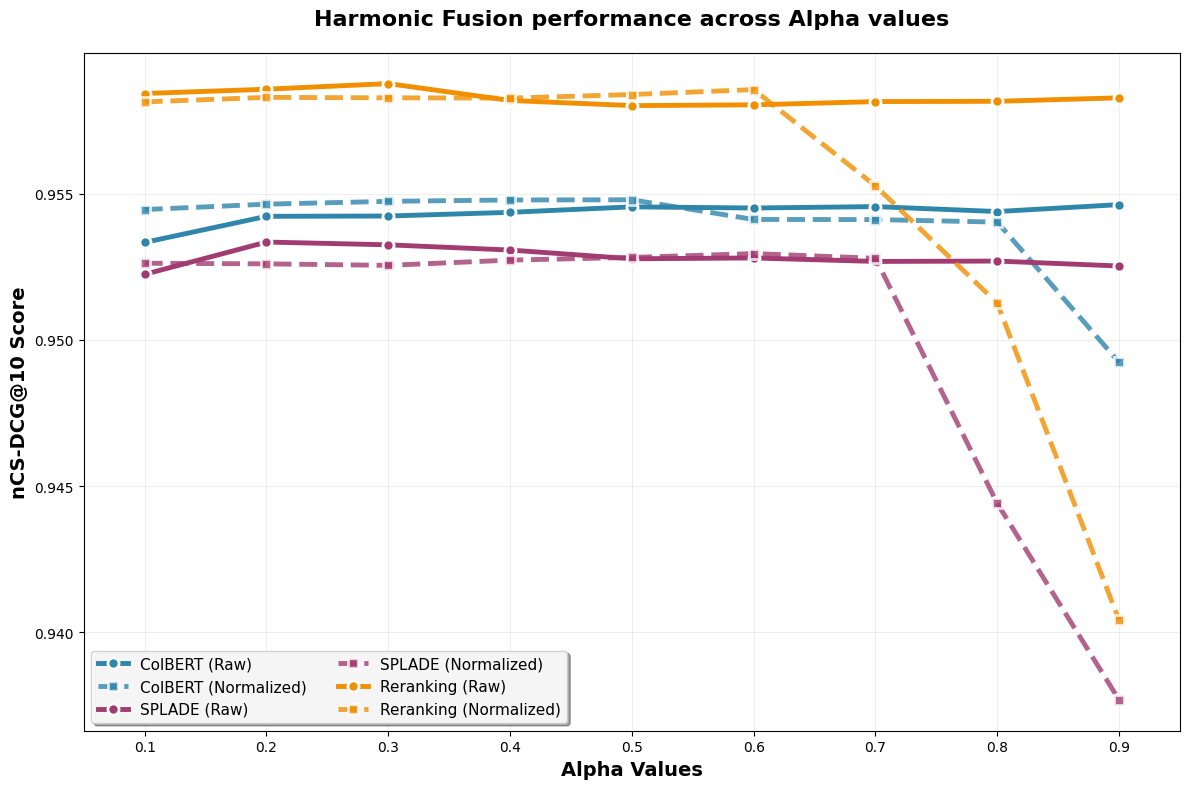

In [21]:
# Set up the plot with professional styling
plt.figure(figsize=(12, 8))
plt.style.use('default')

# Define colors for each dataset
colors = {
    'ColBERT': '#2E86AB',      # Blue
    'SPLADE': '#A23B72',       # Magenta  
    'Reranking': '#F18F01'     # Orange
}

# Dataset names and corresponding dataframes
datasets = {
    'ColBERT': colbert_harmonic_fusion_df,
    'SPLADE': splade_harmonic_fusion_df, 
    'Reranking': reranking_harmonic_fusion_df
}

# Plot each dataset
for dataset_name, df in datasets.items():
    color = colors[dataset_name]
    
    # Filter for Raw and Normalized data
    raw_data = df[df['Fusion Type'] == 'Harmonic (Raw)'].copy()
    norm_data = df[df['Fusion Type'] == 'Harmonic (Normalized)'].copy()
    
    # Sort by Alpha to ensure proper line connection
    raw_data = raw_data.sort_values('Alpha')
    norm_data = norm_data.sort_values('Alpha')
    
    # Plot Raw data with solid line
    # Plot Raw data with enhanced styling
    plt.plot(raw_data['Alpha'], raw_data['nCS-DCG@10'], 
             color=color, linewidth=3.5, linestyle='-', 
             marker='o', markersize=8, markerfacecolor=color,
             markeredgecolor='white', markeredgewidth=2,
             label=f'{dataset_name} (Raw)')
    
    # Plot Normalized data with enhanced styling
    plt.plot(norm_data['Alpha'], norm_data['nCS-DCG@10'], 
             color=color, linewidth=3.5, linestyle='--', 
             marker='s', markersize=7, markerfacecolor=color,
             markeredgecolor='white', markeredgewidth=2,
             label=f'{dataset_name} (Normalized)', alpha=0.8)
# Customize the plot
plt.xlabel('Alpha Values', fontsize=14, fontweight='bold')
plt.ylabel('nCS-DCG@10 Score', fontsize=14, fontweight='bold')
plt.title('Harmonic Fusion performance across Alpha values', 
          fontsize=16, fontweight='bold', pad=20)

# Set x-axis ticks
plt.xticks(np.arange(0.1, 1.0, 0.1))
plt.xlim(0.05, 0.95)

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Customize legend
plt.legend(loc='best', frameon=True, fancybox=True, shadow=True, 
           ncol=2, fontsize=11, framealpha=0.9)

# Improve layout
plt.tight_layout()

# Display the plot
plt.show()

### Basis Fusion (Ridge Regression) Implementation

In [22]:
def _create_basis_features(df, normalize=False, epsilon=1e-9):
    
    # Helper function to create the 11 basis function features.
    if normalize:
        scaler = MinMaxScaler()
        scores = scaler.fit_transform(df[['score']]).flatten()
    else:
        scores = df['score'].values
    
    # Clip values to avoid math errors (e.g., log(0))
    scores = np.clip(scores, epsilon, None)
    sens = df['sensitivity_probability'].clip(lower=epsilon).values
    
    features = pd.DataFrame(index=df.index)
    features['phi_relevance'] = scores
    features['phi_sensitivity'] = sens
    features['phi_relevance_sq'] = scores**2
    features['phi_sensitivity_sq'] = sens**2
    features['phi_interaction'] = scores * sens
    features['phi_relevance_sqrt'] = np.sqrt(scores)
    features['phi_sensitivity_sqrt'] = np.sqrt(sens)
    features['phi_relevance_log'] = np.log(scores)
    features['phi_sensitivity_log'] = np.log(sens)
    features['phi_quad_rel_sens'] = (scores**2) * sens
    features['phi_rel_quad_sens'] = scores * (sens**2)
    return features

# Performs a full Ridge Fusion experiment
def run_ridge_experiment(base_df, Cs, tau, normalize=False):
    
    # Get unique query IDs for a clean split
    unique_qids = base_df['qid'].unique()
    
    # Split query IDs into training and testing sets (e.g., 80/20 split)
    train_qids, test_qids = train_test_split(unique_qids, test_size=0.2, random_state=42)
    
    # Create the actual train and test dataframes
    train_df = base_df[base_df['qid'].isin(train_qids)].copy()
    test_df = base_df[base_df['qid'].isin(test_qids)].copy()

    # Create features for both sets
    train_features = _create_basis_features(train_df, normalize=normalize)
    test_features = _create_basis_features(test_df, normalize=normalize)

    # Create the cost-sensitive target variable for the training set
    y_fused_train = (2**train_df['label'] - 1).astype(float)
    sensitive_mask = train_df['sensitivity_probability'] >= tau
    y_fused_train[sensitive_mask] -= Cs
    
    # Train the RidgeCV model on the training data
    alphas = [0.1, 1 ,10 ,100]
    ridge_cv = RidgeCV(alphas=alphas)
    ridge_cv.fit(train_features, y_fused_train)

    # Make predictions on the unseen test set
    test_df['score'] = ridge_cv.predict(test_features)

    feature_importance = pd.Series(ridge_cv.coef_, index=train_features.columns)
    
    # Sort features by the absolute value of their coefficient to find the most impactful ones
    top_features = feature_importance.abs().sort_values(ascending=False).head(3)
    
    return test_df, top_features

### Basis Fusion Evaluation

In [23]:
colbert_ridge_results = []
splade_ridge_results = []
reranking_ridge_results = []

for name, base_df in data_to_process.items():
  
    base_df.name = name
    
    # Determine which list to append results to
    if name == "ColBERT":
        current_results_list = colbert_ridge_results
    elif name == "SPLADE":
        current_results_list = splade_ridge_results
    else: # Assumes the third model is the reranking one
        current_results_list = reranking_ridge_results

    for norm_type in ['Raw', 'Normalized']:
        normalize = (norm_type == 'Normalized')
        
        # Run the full experiment with train-test split()
        fused_test_df, top_features = run_ridge_experiment(base_df, CS_VALUE, TAU, normalize=normalize)
        print(f'\n Top Features of {name} {norm_type}:\n')
        print(top_features)
        
        # Evaluate the fusion method on the test set
        fusion_metrics = evaluate(fused_test_df, k=K, tau=TAU, Cs=CS_VALUE, qrels_formatted=qrels)
        current_results_list.append({'Fusion Type': f'Ridge ({norm_type})', **fusion_metrics})

# Convert final results to separate DataFrames
colbert_ridge_df = pd.DataFrame(colbert_ridge_results)
splade_ridge_df = pd.DataFrame(splade_ridge_results)
reranking_ridge_df = pd.DataFrame(reranking_ridge_results)


 Top Features of ColBERT Raw:

phi_sensitivity         49.928632
phi_sensitivity_sqrt    30.590922
phi_sensitivity_sq      11.583142
dtype: float64

 Top Features of ColBERT Normalized:

phi_sensitivity         53.461947
phi_sensitivity_sqrt    29.947428
phi_sensitivity_sq      15.102217
dtype: float64

 Top Features of SPLADE Raw:

phi_sensitivity         63.340500
phi_sensitivity_sqrt    38.410814
phi_sensitivity_sq      17.525965
dtype: float64

 Top Features of SPLADE Normalized:

phi_sensitivity         64.580215
phi_sensitivity_sqrt    38.093639
phi_sensitivity_sq      19.191570
dtype: float64

 Top Features of ColBERT→SPLADE Raw:

phi_sensitivity         52.242956
phi_sensitivity_sqrt    30.045732
phi_sensitivity_sq      13.380765
dtype: float64

 Top Features of ColBERT→SPLADE Normalized:

phi_sensitivity         53.039928
phi_sensitivity_sqrt    29.846524
phi_sensitivity_sq      14.384256
dtype: float64


In [24]:
colbert_ridge_df = colbert_ridge_df.round(4)
colbert_ridge_df

,Fusion Type,nCS-DCG@10,nDCG@10,Sens Docs(%)
0,Ridge (Raw),0.9548,0.0047,3.6667
1,Ridge (Normalized),0.9548,0.0047,3.6667


In [25]:
splade_ridge_df = splade_ridge_df.round(4)
splade_ridge_df

,Fusion Type,nCS-DCG@10,nDCG@10,Sens Docs(%)
0,Ridge (Raw),0.9550,0.0101,3.3333
1,Ridge (Normalized),0.9553,0.0109,3.3333


In [26]:
reranking_ridge_df = reranking_ridge_df.round(4)
reranking_ridge_df

,Fusion Type,nCS-DCG@10,nDCG@10,Sens Docs(%)
0,Ridge (Raw),0.9557,0.0050,3.6667
1,Ridge (Normalized),0.9559,0.0054,3.6667


In [27]:
# Start PyTerrier if it hasn't been started
if not pt.started():
    pt.init()

# Prepare the dataframes and their optimal alpha values
# Dictionary mapping model names to their corresponding DataFrames
data_to_process = {
    "ColBERT": colbert_full,
    "SPLADE": splade_full,
    "ColBERT+SPLADE": rerank_full  # Change this from "ColBERT→SPLADE"
}

optimal_alphas = {
    "ColBERT": {"Linear (Raw)": 0.2, "Linear (Normalized)": 0.6, "Harmonic (Raw)": 0.9, "Harmonic (Normalized)": 0.5},
    "SPLADE": {"Linear (Raw)": 0.1, "Linear (Normalized)": 0.7, "Harmonic (Raw)": 0.2, "Harmonic (Normalized)": 0.6},
    "ColBERT+SPLADE": {"Linear (Raw)": 0.1, "Linear (Normalized)": 0.5, "Harmonic (Raw)": 0.3, "Harmonic (Normalized)": 0.6}
}

Java started and loaded: pyterrier.java, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipykernel_19879/2641015517.py:3: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


### Statistical Tests

In [28]:
# Evaluate baseline model using raw scores only
def evaluate_baseline(model_name, base_df, topics_df, qrels_df):
    
    # Evaluate baseline model (raw scores only)
    baseline_run = base_df[['qid', 'docno', 'score']].copy()
    # Run PyTerrier experiment for baseline
    exp = pt.Experiment(
        [baseline_run],
        topics_df,
        qrels_df,
        eval_metrics=['ndcg_cut_10', 'map', 'P_10'],
        names=['Baseline']
    )
    row = exp.iloc[0].to_dict()
    # Return results as a dictionary
    return {
        'Model': model_name,
        'Method': 'Baseline',
        'Alpha': '-',
        'System_Name': row.get('name', 'Baseline'),
        'nDCG@10': row.get('ndcg_cut_10', 0),
        'nDCG@10_pvalue': '-',
        'MAP': row.get('map', 0),
        'MAP_pvalue': '-',
        'P@10': row.get('P_10', 0),
        'P@10_pvalue': '-',
    }


# Evaluate linear and harmonic fusion methods
def evaluate_fusions(model_name, base_df, topics_df, qrels_df, optimal_alphas):
    # Evaluate linear and harmonic fusions (raw + normalized)
    results = []
    baseline_run = base_df[['qid', 'docno', 'score']].copy()

    fusion_methods = [
        (fuse_linear_scores, 'Linear'),
        (fuse_harmonic_scores, 'Harmonic')
    ]

    for fusion_func, func_name in fusion_methods:
        for norm_type in ['Raw', 'Normalized']:
            fusion_key = f'{func_name} ({norm_type})'
            alpha = optimal_alphas[model_name][fusion_key]
            normalize = (norm_type == 'Normalized')


            # Apply fusion with selected alpha and normalization
            fused_df = fusion_func(base_df, alpha, normalize=normalize)
            fused_run = fused_df[['qid', 'docno', 'score']].copy()

            # Run PyTerrier experiment with baseline for statistical significance
            exp = pt.Experiment(
                [baseline_run, fused_run],
                topics_df,
                qrels_df,
                eval_metrics=['ndcg_cut_10', 'map', 'P_10'],
                names=['Baseline', f'{func_name}_{norm_type}'],
                baseline=0,
                correction='bonferroni'
            )

            row = exp.iloc[1].to_dict()
            results.append({
                'Model': model_name,
                'Method': fusion_key,
                'Alpha': alpha,
                'System_Name': row.get('name', f'{func_name}_{norm_type}'),
                'nDCG@10': row.get('ndcg_cut_10', 0),
                'nDCG@10_pvalue': row.get('ndcg_cut_10 p-value corrected', 1.0),
                'MAP': row.get('map', 0),
                'MAP_pvalue': row.get('map p-value corrected', 1.0),
                'P@10': row.get('P_10', 0),
                'P@10_pvalue': row.get('P_10 p-value corrected', 1.0),
            })
    return results


# Evaluate Ridge regression fusion method
def evaluate_ridge(model_name, base_df, topics_df, qrels_df):
    # Evaluate Ridge fusion (raw + normalized)
    results = []
    for norm_type in ['Raw', 'Normalized']:
        normalize = (norm_type == 'Normalized')

        # Run Ridge experiment (unpack tuple)
        ridge_df, top_features = run_ridge_experiment(base_df, CS_VALUE, TAU, normalize=normalize)
        ridge_run = ridge_df[['qid', 'docno', 'score']].copy()

        # Restrict baseline to test queries only
        test_qids = ridge_df['qid'].unique()
        baseline_test = base_df[base_df['qid'].isin(test_qids)][['qid', 'docno', 'score']].copy()

        # Run PyTerrier experiment with baseline for significance testing
        exp = pt.Experiment(
            [baseline_test, ridge_run],
            topics_df[topics_df['qid'].isin(test_qids)],
            qrels_df[qrels_df['qid'].isin(test_qids)],
            eval_metrics=['ndcg_cut_10', 'map', 'P_10'],
            names=['Baseline', f'Ridge_{norm_type}'],
            baseline=0,
            correction='bonferroni'
        )

        row = exp.iloc[1].to_dict()
        results.append({
            'Model': model_name,
            'Method': f'Ridge ({norm_type})',
            'Alpha': '-',
            'System_Name': row.get('name', f'Ridge_{norm_type}'),
            'nDCG@10': row.get('ndcg_cut_10', 0),
            'nDCG@10_pvalue': row.get('ndcg_cut_10 p-value corrected', 1.0),
            'MAP': row.get('map', 0),
            'MAP_pvalue': row.get('map p-value corrected', 1.0),
            'P@10': row.get('P_10', 0),
            'P@10_pvalue': row.get('P_10 p-value corrected', 1.0),
        })
    return results


# Gather all evaluation results for a model
def gather_results_for_model(model_name, base_df, topics_df, qrels_df, optimal_alphas):
    # Run baseline, fusion, and Ridge evaluations for one model
    print(f"\nRunning evaluations for {model_name}...")
    results = []
    results.append(evaluate_baseline(model_name, base_df, topics_df, qrels_df))
    results.extend(evaluate_fusions(model_name, base_df, topics_df, qrels_df, optimal_alphas))
    results.extend(evaluate_ridge(model_name, base_df, topics_df, qrels_df))
    return results


# Prepare models and their data
data_to_process = {
    "ColBERT": colbert_full,
    "SPLADE": splade_full,
    "ColBERT+SPLADE": rerank_full
}

# Define optimal alphas for fusion methods
optimal_alphas = {
    "ColBERT": {
        "Linear (Raw)": 0.2, "Linear (Normalized)": 0.6,
        "Harmonic (Raw)": 0.9, "Harmonic (Normalized)": 0.5
    },
    "SPLADE": {
        "Linear (Raw)": 0.1, "Linear (Normalized)": 0.7,
        "Harmonic (Raw)": 0.2, "Harmonic (Normalized)": 0.6
    },
    "ColBERT+SPLADE": {
        "Linear (Raw)": 0.1, "Linear (Normalized)": 0.5,
        "Harmonic (Raw)": 0.3, "Harmonic (Normalized)": 0.6
    }
}

# Convert topics and qrels to DataFrames
topics_list = list(dataset.queries_iter())
topics_df = pd.DataFrame([{'qid': t.query_id, 'query': t.text} for t in topics_list])
qrels_list = list(dataset.qrels_iter())
qrels_df = pd.DataFrame([{'qid': q.query_id, 'docno': q.doc_id, 'label': q.relevance} for q in qrels_list])

# Run evaluations for all models
all_statistical_results = []
for model_name, base_df in data_to_process.items():
    results = gather_results_for_model(model_name, base_df, topics_df, qrels_df, optimal_alphas)
    all_statistical_results.extend(results)

# Convert results to DataFrame
statistical_results_df = pd.DataFrame(all_statistical_results)

# Separate DataFrames per model for easier handling
colbert_stats_df = statistical_results_df[statistical_results_df['Model'] == 'ColBERT'].copy()
splade_stats_df = statistical_results_df[statistical_results_df['Model'] == 'SPLADE'].copy()
rerank_stats_df = statistical_results_df[statistical_results_df['Model'] == 'ColBERT+SPLADE'].copy()

# Define method display order
method_order = ["Baseline", "Linear (Raw)", "Linear (Normalized)",
                "Harmonic (Raw)", "Harmonic (Normalized)",
                "Ridge (Raw)", "Ridge (Normalized)"]

# Sort and format each model's DataFrame
for df in [colbert_stats_df, splade_stats_df, rerank_stats_df]:
    if not df.empty:
        df.drop('Model', axis=1, inplace=True)  # remove redundant column
        df['Method'] = pd.Categorical(df['Method'], categories=method_order, ordered=True)
        df.sort_values('Method', inplace=True)
        df.reset_index(drop=True, inplace=True)

# Round numerical evaluation metrics for readability
numerical_cols = ['Alpha', 'nDCG@10', 'nDCG@10_pvalue', 'MAP', 'MAP_pvalue', 'P@10', 'P@10_pvalue']
for df in [colbert_stats_df, splade_stats_df, rerank_stats_df, statistical_results_df]:
    if not df.empty:
        for col in numerical_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce').round(4)

print("Finished evaluations.")


Running evaluations for ColBERT...

Running evaluations for SPLADE...

Running evaluations for ColBERT+SPLADE...
Finished evaluations.


In [29]:
colbert_stats_df

,Method,Alpha,System_Name,nDCG@10,nDCG@10_pvalue,MAP,MAP_pvalue,P@10,P@10_pvalue
0,Baseline,NaN,Baseline,0.1164,NaN,0.0728,NaN,0.1100,NaN
1,Linear (Raw),0.2,Linear_Raw,0.0989,0.0020,0.0631,0.0000,0.0960,0.0020
2,Linear (Normalized),0.6,Linear_Normalized,0.0991,0.0036,0.0628,0.0000,0.0953,0.0016
3,Harmonic (Raw),0.9,Harmonic_Raw,0.0971,0.0011,0.0622,0.0000,0.0940,0.0009
4,Harmonic (Normalized),0.5,Harmonic_Normalized,0.0997,0.0048,0.0631,0.0000,0.0960,0.0020
5,Ridge (Raw),NaN,Ridge_Raw,0.0234,0.0022,0.0190,0.0020,0.0267,0.0023
6,Ridge (Normalized),NaN,Ridge_Normalized,0.0236,0.0022,0.0193,0.0018,0.0267,0.0023


In [30]:
splade_stats_df

,Method,Alpha,System_Name,nDCG@10,nDCG@10_pvalue,MAP,MAP_pvalue,P@10,P@10_pvalue
0,Baseline,NaN,Baseline,0.1730,NaN,0.1251,NaN,0.1553,NaN
1,Linear (Raw),0.1,Linear_Raw,0.1421,0.0001,0.1000,0.0000,0.1280,0.0001
2,Linear (Normalized),0.7,Linear_Normalized,0.1421,0.0001,0.1000,0.0000,0.1280,0.0001
3,Harmonic (Raw),0.2,Harmonic_Raw,0.1451,0.0010,0.0981,0.0000,0.1247,0.0000
4,Harmonic (Normalized),0.6,Harmonic_Normalized,0.1422,0.0001,0.1003,0.0000,0.1280,0.0001
5,Ridge (Raw),NaN,Ridge_Raw,0.0504,0.0019,0.0318,0.0013,0.0467,0.0034
6,Ridge (Normalized),NaN,Ridge_Normalized,0.0545,0.0030,0.0345,0.0018,0.0500,0.0035


In [31]:
rerank_stats_df

,Method,Alpha,System_Name,nDCG@10,nDCG@10_pvalue,MAP,MAP_pvalue,P@10,P@10_pvalue
0,Baseline,NaN,Baseline,0.1517,NaN,0.0891,NaN,0.1353,NaN
1,Linear (Raw),0.1,Linear_Raw,0.1235,0.0006,0.0724,0.0000,0.1187,0.0040
2,Linear (Normalized),0.5,Linear_Normalized,0.1222,0.0004,0.0720,0.0000,0.1167,0.0015
3,Harmonic (Raw),0.3,Harmonic_Raw,0.1237,0.0010,0.0717,0.0000,0.1153,0.0012
4,Harmonic (Normalized),0.6,Harmonic_Normalized,0.1236,0.0007,0.0727,0.0000,0.1180,0.0030
5,Ridge (Raw),NaN,Ridge_Raw,0.0252,0.0075,0.0199,0.0013,0.0333,0.0191
6,Ridge (Normalized),NaN,Ridge_Normalized,0.0268,0.0080,0.0211,0.0015,0.0367,0.0209


### Extracting Splade Scores for quantitative analysis

In [32]:
# Linear fusion with weight 0.1
splade_l = fuse_linear_scores(splade_full, 0.1)

# Harmonic fusion with weight 0.2
splade_h = fuse_harmonic_scores(splade_full, 0.2)

# Baseline ridge regression experiment
splade_b = run_ridge_experiment(splade_full, CS_VALUE, TAU)
splade_b = splade_b[0] 

def recompute_ranks(df):
    # Rank documents per query by descending score
    df = (
        df.sort_values(["qid", "score"], ascending=[True, False])
          .groupby("qid", group_keys=False)
          .apply(lambda g: g.assign(rank=range(1, len(g) + 1)))
          .reset_index(drop=True)
    )
    return df

# Linear fusion
splade_l = fuse_linear_scores(splade_full, 0.1)
splade_l = recompute_ranks(splade_l)

# Harmonic fusion
splade_h = fuse_harmonic_scores(splade_full, 0.2)
splade_h = recompute_ranks(splade_h)

# Baseline ridge
splade_b = run_ridge_experiment(splade_full, CS_VALUE, TAU)[0]
splade_b = recompute_ranks(splade_b)

### Sensitive documents retrieved using SPLADE using each fusion method

In [33]:
def summarize_models_macro_percentage(results, topk=10):
    
    # Summarize models with the average percentage of sensitive docs in top-k per query (macro average) and total number of sensitive docs in top-k.
    summary_rows = []

    for name, df in results.items():
        df['qid'] = df['qid'].astype(str)  # ensure qid is string
        per_query_percent = []
        total_sensitive_docs = 0

        # Compute percentage of sensitive docs per query
        for qid, group in df.groupby('qid'):
            topk_docs = group.sort_values('score', ascending=False).head(topk)
            sensitive_count = (topk_docs['sensitivity'] == 1).sum()
            percent_sensitive = (sensitive_count / topk) * 100
            per_query_percent.append(percent_sensitive)
            total_sensitive_docs += sensitive_count

        # Macro average: average percentage sensitive docs per query
        macro_avg_percent = sum(per_query_percent) / len(per_query_percent) if per_query_percent else 0

        summary_rows.append({
            "Model": name,
            "No. of Sens Docs": total_sensitive_docs,
            "Avg Sens Docs (%)": round(macro_avg_percent, 2)
        })

    return pd.DataFrame(summary_rows)

results = {
    "Splade Baseline": splade_full,
    "Splade Linear": splade_l,
    "Splade Harmonic": splade_h,
    "Splade Basis": splade_b
}

summary_table = summarize_models_macro_percentage(results, topk=10)
summary_table

,Model,No. of Sens Docs,Avg Sens Docs (%)
0,Splade Baseline,164,10.93
1,Splade Linear,14,0.93
2,Splade Harmonic,8,0.53
3,Splade Basis,10,3.33
